In [12]:
# ============================================================
# H2: Initialization experiment
# ============================================================

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import importlib
from pathlib import Path

from scratch import *
import scratch

importlib.reload(scratch)


<module 'scratch' from '/Users/debashisgupta/Desktop/Course/K-UTD/Fall-26/DL/K-Project1/Code/scratch.py'>

In [13]:
EXPERIMENT_EPOCHS = 100
EXPERIMENT_SEEDS = generate_experiment_seeds(base_seed=SPLIT_SEED, number_of_seeds=3)
H3_OUTPUT_DIR = Path("output/h3")

os.makedirs(
    H3_OUTPUT_DIR,
    exist_ok=True
)
# H3_LEARNING_RATES = [
#     0.001,
#     0.01,
#     0.1,
#     0.5,
#     0.9
# ]

print("H3 output folder:", H3_OUTPUT_DIR)
# print("Learning rates:", H3_LEARNING_RATES)
print("Experiment seeds:", EXPERIMENT_SEEDS)

print("\nLoading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprossing data...")

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)


H3 output folder: output/h3
Experiment seeds: [654571, 89250, 773955]

Loading MNIST data...
Preprossing data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


In [14]:
H3_ACTIVATIONS = ["relu", "tanh", "sigmoid"]

H3_HIDDEN_SIZE = 128
H3_INITIALIZATION = "small"
H3_LEARNING_RATE = 0.1
H3_BATCH_SIZE = 128
H3_EPOCHS = 100

# Used to measure convergence speed
H3_ACCURACY_THRESHOLD = 0.95


In [15]:
EXPERIMENT_SEEDS = generate_experiment_seeds(base_seed=SPLIT_SEED, number_of_seeds=3)
print("\nControlled settings")
print("Hidden size:", H3_HIDDEN_SIZE)
print("Initialization:", H3_INITIALIZATION)
print("Learning rate:", H3_LEARNING_RATE)
print("Batch size:", H3_BATCH_SIZE)
print("Epochs:", H3_EPOCHS)
print("Activations:", H3_ACTIVATIONS)
print("Experiment seeds:", EXPERIMENT_SEEDS)



Controlled settings
Hidden size: 128
Initialization: small
Learning rate: 0.1
Batch size: 128
Epochs: 100
Activations: ['relu', 'tanh', 'sigmoid']
Experiment seeds: [654571, 89250, 773955]


In [16]:
h3_history_rows = []
h3_final_rows = []

total_runs = len(H3_ACTIVATIONS) * len(EXPERIMENT_SEEDS)
run_number = 0

for activation in H3_ACTIVATIONS:

    print("\n" + "=" * 70)
    print(f"Activation: {activation.upper()}")
    print("=" * 70)

    for seed in EXPERIMENT_SEEDS:

        run_number += 1

        print(
            f"\nRun {run_number}/{total_runs} | "
            f"activation={activation} | seed={seed}"
        )

        # Train the model
        parameters, history = train_model(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            hidden_size=H3_HIDDEN_SIZE,
            activation=activation,
            initialization=H3_INITIALIZATION,
            learning_rate=H3_LEARNING_RATE,
            batch_size=H3_BATCH_SIZE,
            epochs=H3_EPOCHS,
            seed=seed,
            verbose=True
        )

        # Store every epoch so that mean and standard-deviation
        # curves can be calculated later.
        number_of_epochs = len(history["train_loss"])

        for epoch_index in range(number_of_epochs):

            h3_history_rows.append({
                "activation": activation,
                "seed": seed,
                "epoch": epoch_index + 1,
                "train_loss": history["train_loss"][epoch_index],
                "train_accuracy": history["train_accuracy"][epoch_index],
                "val_loss": history["val_loss"][epoch_index],
                "val_accuracy": history["val_accuracy"][epoch_index]
            })

        # Evaluate the final model again.
        # This measures both training and validation performance
        # using the final parameters.
        final_train_loss, final_train_accuracy = evaluate_model(
            X_train,
            y_train,
            parameters,
            activation
        )

        final_val_loss, final_val_accuracy = evaluate_model(
            X_val,
            y_val,
            parameters,
            activation
        )

        # Find the first epoch at which validation accuracy
        # reached 95%. This helps measure convergence speed.
        val_accuracy_array = np.asarray(
            history["val_accuracy"],
            dtype=np.float64
        )

        threshold_positions = np.where(
            val_accuracy_array >= H3_ACCURACY_THRESHOLD
        )[0]

        if len(threshold_positions) > 0:
            epoch_to_95 = int(threshold_positions[0] + 1)
        else:
            epoch_to_95 = np.nan

        h3_final_rows.append({
            "activation": activation,
            "seed": seed,
            "final_train_loss": final_train_loss,
            "final_train_accuracy": final_train_accuracy,
            "final_val_loss": final_val_loss,
            "final_val_accuracy": final_val_accuracy,
            "epoch_to_95_val_accuracy": epoch_to_95,
            "reached_95_val_accuracy": not np.isnan(epoch_to_95)
        })

        epoch_message = (
            str(epoch_to_95)
            if not np.isnan(epoch_to_95)
            else "not reached"
        )

        print(
            f"Completed | "
            f"Train accuracy={100 * final_train_accuracy:.2f}% | "
            f"Validation accuracy={100 * final_val_accuracy:.2f}% | "
            f"Epoch to 95% validation accuracy={epoch_message}"
        )




Activation: RELU

Run 1/9 | activation=relu | seed=654571
Epoch 1: Train loss=0.8450, Train accuracy=0.7704, Val loss=0.3844, Val accuracy=0.8892
Epoch 10: Train loss=0.1387, Train accuracy=0.9605, Val loss=0.1445, Val accuracy=0.9579
Epoch 20: Train loss=0.0730, Train accuracy=0.9803, Val loss=0.0970, Val accuracy=0.9715
Epoch 30: Train loss=0.0452, Train accuracy=0.9884, Val loss=0.0826, Val accuracy=0.9748
Epoch 40: Train loss=0.0300, Train accuracy=0.9937, Val loss=0.0751, Val accuracy=0.9768
Epoch 50: Train loss=0.0209, Train accuracy=0.9964, Val loss=0.0748, Val accuracy=0.9780
Epoch 60: Train loss=0.0150, Train accuracy=0.9982, Val loss=0.0723, Val accuracy=0.9792
Epoch 70: Train loss=0.0112, Train accuracy=0.9991, Val loss=0.0735, Val accuracy=0.9795
Epoch 80: Train loss=0.0086, Train accuracy=0.9995, Val loss=0.0730, Val accuracy=0.9785
Epoch 90: Train loss=0.0068, Train accuracy=0.9997, Val loss=0.0734, Val accuracy=0.9796
Epoch 100: Train loss=0.0055, Train accuracy=0.9999,


H3 FINAL RESULTS: MEAN ± SAMPLE STANDARD DEVIATION


,Activation,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Runs Reaching 95%,Epoch to 95%
0,relu,0.0054 ± 0.0001,99.99% ± 0.00%,0.0776 ± 0.0027,97.86% ± 0.09%,3/3,7.67 ± 1.15
1,sigmoid,0.0639 ± 0.0012,98.31% ± 0.04%,0.0941 ± 0.0007,97.19% ± 0.04%,3/3,32.33 ± 0.58
2,tanh,0.0085 ± 0.0001,99.96% ± 0.00%,0.0710 ± 0.0004,97.85% ± 0.07%,3/3,9.00 ± 0.00


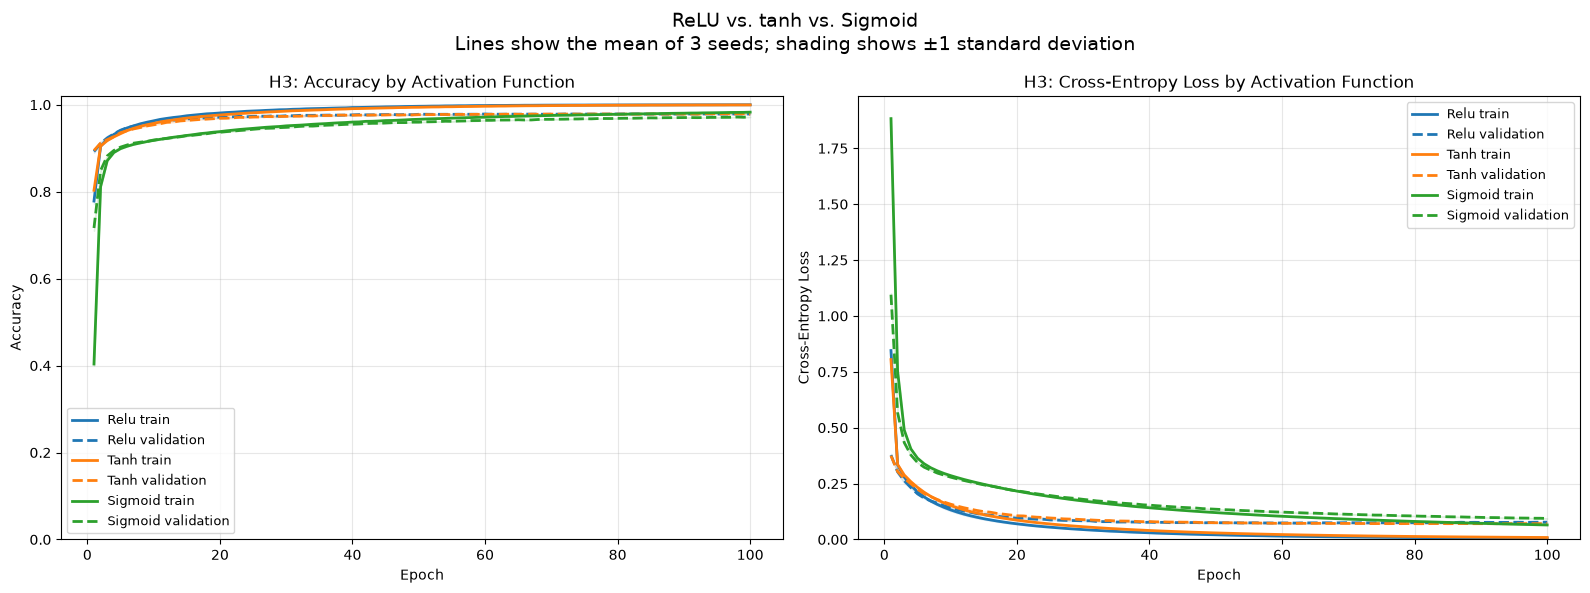


Ranking by mean final validation accuracy
1. Relu: 97.86% ± 0.09% validation accuracy; reached 95% in an average of 7.67 epochs
2. Tanh: 97.85% ± 0.07% validation accuracy; reached 95% in an average of 9.00 epochs
3. Sigmoid: 97.19% ± 0.04% validation accuracy; reached 95% in an average of 32.33 epochs

Saved H3 files:
- output/h3/h3_activation_curves.pdf
- output/h3/h3_activation_curves.png
- output/h3/h3_all_run_histories.csv
- output/h3/h3_configuration.csv
- output/h3/h3_epoch_mean_std.csv
- output/h3/h3_final_results_by_seed.csv
- output/h3/h3_final_summary_formatted.csv
- output/h3/h3_final_summary_numeric.csv


In [17]:

h3_history_df = pd.DataFrame(h3_history_rows)
h3_final_df = pd.DataFrame(h3_final_rows)


# ------------------------------------------------------------
# 6. Calculate mean and sample standard deviation per epoch
# ------------------------------------------------------------

h3_epoch_summary_df = (
    h3_history_df
    .groupby(
        ["activation", "epoch"],
        as_index=False
    )
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        train_accuracy_mean=("train_accuracy", "mean"),
        train_accuracy_std=("train_accuracy", "std"),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
        val_accuracy_mean=("val_accuracy", "mean"),
        val_accuracy_std=("val_accuracy", "std")
    )
)


# ------------------------------------------------------------
# 7. Calculate final mean ± standard deviation
# ------------------------------------------------------------

h3_final_summary_df = (
    h3_final_df
    .groupby(
        "activation",
        as_index=False
    )
    .agg(
        train_loss_mean=("final_train_loss", "mean"),
        train_loss_std=("final_train_loss", "std"),
        train_accuracy_mean=("final_train_accuracy", "mean"),
        train_accuracy_std=("final_train_accuracy", "std"),
        val_loss_mean=("final_val_loss", "mean"),
        val_loss_std=("final_val_loss", "std"),
        val_accuracy_mean=("final_val_accuracy", "mean"),
        val_accuracy_std=("final_val_accuracy", "std"),
        runs_reaching_95=(
            "reached_95_val_accuracy",
            "sum"
        ),
        mean_epoch_to_95=(
            "epoch_to_95_val_accuracy",
            "mean"
        ),
        std_epoch_to_95=(
            "epoch_to_95_val_accuracy",
            "std"
        )
    )
)


# ------------------------------------------------------------
# 8. Make a formatted table for reading and reporting
# ------------------------------------------------------------

h3_display_rows = []

for _, row in h3_final_summary_df.iterrows():

    if pd.isna(row["mean_epoch_to_95"]):
        convergence_text = "Not reached"
    elif pd.isna(row["std_epoch_to_95"]):
        convergence_text = (
            f"{row['mean_epoch_to_95']:.2f}"
        )
    else:
        convergence_text = (
            f"{row['mean_epoch_to_95']:.2f} "
            f"± {row['std_epoch_to_95']:.2f}"
        )

    h3_display_rows.append({
        "Activation": row["activation"],
        "Train Loss": (
            f"{row['train_loss_mean']:.4f} "
            f"± {row['train_loss_std']:.4f}"
        ),
        "Train Accuracy": (
            f"{100 * row['train_accuracy_mean']:.2f}% "
            f"± {100 * row['train_accuracy_std']:.2f}%"
        ),
        "Validation Loss": (
            f"{row['val_loss_mean']:.4f} "
            f"± {row['val_loss_std']:.4f}"
        ),
        "Validation Accuracy": (
            f"{100 * row['val_accuracy_mean']:.2f}% "
            f"± {100 * row['val_accuracy_std']:.2f}%"
        ),
        "Runs Reaching 95%": (
            f"{int(row['runs_reaching_95'])}/"
            f"{len(EXPERIMENT_SEEDS)}"
        ),
        "Epoch to 95%": convergence_text
    })

h3_display_df = pd.DataFrame(h3_display_rows)


print("\n" + "=" * 90)
print("H3 FINAL RESULTS: MEAN ± SAMPLE STANDARD DEVIATION")
print("=" * 90)

display(h3_display_df)


# ------------------------------------------------------------
# 9. Save all numerical results as CSV files
# ------------------------------------------------------------
H3_OUTPUT_DIR = Path(H3_OUTPUT_DIR)
h3_history_df.to_csv(
    H3_OUTPUT_DIR / "h3_all_run_histories.csv",
    index=False
)

h3_epoch_summary_df.to_csv(
    H3_OUTPUT_DIR / "h3_epoch_mean_std.csv",
    index=False
)

h3_final_df.to_csv(
    H3_OUTPUT_DIR / "h3_final_results_by_seed.csv",
    index=False
)

h3_final_summary_df.to_csv(
    H3_OUTPUT_DIR / "h3_final_summary_numeric.csv",
    index=False
)

h3_display_df.to_csv(
    H3_OUTPUT_DIR / "h3_final_summary_formatted.csv",
    index=False
)


# ------------------------------------------------------------
# 10. Save the experimental configuration
# ------------------------------------------------------------

h3_configuration_df = pd.DataFrame({
    "setting": [
        "hypothesis",
        "activations",
        "hidden_size",
        "initialization",
        "learning_rate",
        "batch_size",
        "epochs",
        "accuracy_threshold",
        "training_seeds",
        "split_seed"
    ],
    "value": [
        (
            "ReLU will converge faster than tanh and sigmoid "
            "under fixed training conditions."
        ),
        ", ".join(H3_ACTIVATIONS),
        H3_HIDDEN_SIZE,
        H3_INITIALIZATION,
        H3_LEARNING_RATE,
        H3_BATCH_SIZE,
        H3_EPOCHS,
        H3_ACCURACY_THRESHOLD,
        ", ".join(map(str, EXPERIMENT_SEEDS)),
        SPLIT_SEED
    ]
})

h3_configuration_df.to_csv(
    H3_OUTPUT_DIR / "h3_configuration.csv",
    index=False
)


# ------------------------------------------------------------
# 11. Plot mean accuracy and loss with ±1 std shading
# ------------------------------------------------------------

activation_colors = {
    "relu": "tab:blue",
    "tanh": "tab:orange",
    "sigmoid": "tab:green"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

accuracy_axis = axes[0]
loss_axis = axes[1]


for activation in H3_ACTIVATIONS:

    activation_data = (
        h3_epoch_summary_df[
            h3_epoch_summary_df["activation"] == activation
        ]
        .sort_values("epoch")
    )

    epochs = activation_data["epoch"].to_numpy()

    color = activation_colors[activation]


    # --------------------------------------------------------
    # Accuracy plot
    # --------------------------------------------------------

    train_accuracy_mean = activation_data[
        "train_accuracy_mean"
    ].to_numpy()

    train_accuracy_std = activation_data[
        "train_accuracy_std"
    ].to_numpy()

    val_accuracy_mean = activation_data[
        "val_accuracy_mean"
    ].to_numpy()

    val_accuracy_std = activation_data[
        "val_accuracy_std"
    ].to_numpy()


    accuracy_axis.plot(
        epochs,
        train_accuracy_mean,
        color=color,
        linestyle="-",
        linewidth=2,
        label=f"{activation.capitalize()} train"
    )

    accuracy_axis.fill_between(
        epochs,
        np.clip(
            train_accuracy_mean - train_accuracy_std,
            0,
            1
        ),
        np.clip(
            train_accuracy_mean + train_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.12
    )

    accuracy_axis.plot(
        epochs,
        val_accuracy_mean,
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{activation.capitalize()} validation"
    )

    accuracy_axis.fill_between(
        epochs,
        np.clip(
            val_accuracy_mean - val_accuracy_std,
            0,
            1
        ),
        np.clip(
            val_accuracy_mean + val_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.12
    )


    # --------------------------------------------------------
    # Loss plot
    # --------------------------------------------------------

    train_loss_mean = activation_data[
        "train_loss_mean"
    ].to_numpy()

    train_loss_std = activation_data[
        "train_loss_std"
    ].to_numpy()

    val_loss_mean = activation_data[
        "val_loss_mean"
    ].to_numpy()

    val_loss_std = activation_data[
        "val_loss_std"
    ].to_numpy()


    loss_axis.plot(
        epochs,
        train_loss_mean,
        color=color,
        linestyle="-",
        linewidth=2,
        label=f"{activation.capitalize()} train"
    )

    loss_axis.fill_between(
        epochs,
        np.maximum(
            train_loss_mean - train_loss_std,
            0
        ),
        train_loss_mean + train_loss_std,
        color=color,
        alpha=0.12
    )

    loss_axis.plot(
        epochs,
        val_loss_mean,
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{activation.capitalize()} validation"
    )

    loss_axis.fill_between(
        epochs,
        np.maximum(
            val_loss_mean - val_loss_std,
            0
        ),
        val_loss_mean + val_loss_std,
        color=color,
        alpha=0.12
    )


# Accuracy formatting
accuracy_axis.set_title(
    "H3: Accuracy by Activation Function"
)
accuracy_axis.set_xlabel("Epoch")
accuracy_axis.set_ylabel("Accuracy")
accuracy_axis.set_ylim(0, 1.02)
accuracy_axis.grid(alpha=0.3)
accuracy_axis.legend(fontsize=9)


# Loss formatting
loss_axis.set_title(
    "H3: Cross-Entropy Loss by Activation Function"
)
loss_axis.set_xlabel("Epoch")
loss_axis.set_ylabel("Cross-Entropy Loss")
loss_axis.set_ylim(bottom=0)
loss_axis.grid(alpha=0.3)
loss_axis.legend(fontsize=9)


fig.suptitle(
    "ReLU vs. tanh vs. Sigmoid\n"
    "Lines show the mean of 3 seeds; shading shows ±1 standard deviation",
    fontsize=14
)

plt.tight_layout()

figure_png_path = H3_OUTPUT_DIR / "h3_activation_curves.png"
figure_pdf_path = H3_OUTPUT_DIR / "h3_activation_curves.pdf"

plt.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_pdf_path,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 12. Print ranking by final validation accuracy
# ------------------------------------------------------------

h3_ranking_df = (
    h3_final_summary_df[
        [
            "activation",
            "val_accuracy_mean",
            "val_accuracy_std",
            "val_loss_mean",
            "val_loss_std",
            "mean_epoch_to_95"
        ]
    ]
    .sort_values(
        "val_accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nRanking by mean final validation accuracy")

for rank, row in h3_ranking_df.iterrows():

    if pd.isna(row["mean_epoch_to_95"]):
        speed_text = "did not reach 95%"
    else:
        speed_text = (
            f"reached 95% in an average of "
            f"{row['mean_epoch_to_95']:.2f} epochs"
        )

    print(
        f"{rank + 1}. {row['activation'].capitalize()}: "
        f"{100 * row['val_accuracy_mean']:.2f}% "
        f"± {100 * row['val_accuracy_std']:.2f}% validation accuracy; "
        f"{speed_text}"
    )


# ------------------------------------------------------------
# 13. Print saved file names
# ------------------------------------------------------------

print("\nSaved H3 files:")

for saved_file in sorted(H3_OUTPUT_DIR.iterdir()):
    print("-", saved_file)